In [2]:
# Results directory / file definitions and modules imports
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from polarity.utilities import figure_helper as fh
from polarity.utilities.metric_functions import polarity_measure, find_interface
from polarity.model_enums import MODELS

# Model and data directory
results_dir = fh.DATA_DIR / "sensitivity_establishment_PAR3ND"
file_list = list(Path(results_dir).glob("*.pkl"))
params = [f.stem.replace("_sweep", "") for f in file_list]


In [4]:
# Functions definitions (loading data and plotting heat maps)
def read_simulation_data(param_name):
    filename = results_dir / f"{param_name}_sweep.pkl"
    with open(filename, "rb") as f:
        res_list = pickle.load(f)
    return res_list

def get_polarity_measures(param_name):
    res_list = read_simulation_data(param_name)
    res, setup = res_list[0]
    df = pd.DataFrame(
        {"parameter": param_name,
        "multiplier": [setup[f"{param_name}_mult"] for res, setup in res_list],
        "polarity": [polarity_measure(setup["X"], res.y[:,-1], species = setup["Species"]) for res, setup in res_list],
        "interface": [find_interface(setup["X"], res.y[:,-1], species = setup["Species"]) for res, setup in res_list] }
    )
    return df

def plot_heatmap(ax, metrics_df, metric_name, cmap = "viridis"):    
    # For heatmap: index = y value, columns = x values, values = z value
    heatmap_data = metrics_df.pivot(index="parameter", columns="multiplier", values=metric_name)

    hm = sns.heatmap(heatmap_data, cmap=cmap, ax=ax, vmin = 0, vmax = 1, xticklabels=20,
                     cbar_kws={'orientation': 'horizontal','location': 'top'})
    cbar = hm.collections[0].colorbar
    cbar.outline.set_visible(True)
    cbar.outline.set_edgecolor("black")
    cbar.outline.set_linewidth(1.0)
    cbar.ax.set_title(metric_name.capitalize(), pad=8, fontsize = fh.label_font_size)   # title above the bar

    ax.set_yticklabels([fh.format_param_label_math(lbl) for lbl in heatmap_data.index])
    ax.set_xlabel("Scaling Coefficient, $\\alpha$")
    ax.set_ylabel("Parameter")
    ax.spines[:].set_visible(True)

# Section 3.2 Establishment of polarity

In [5]:
# Read in all the parameter sweeps and concatenate into a single data frame
metrics = pd.concat([get_polarity_measures(param) for param in params], ignore_index=True)
# Order by minimum polarity value for each parameter
metrics = metrics.sort_values(by="polarity", ascending=True)

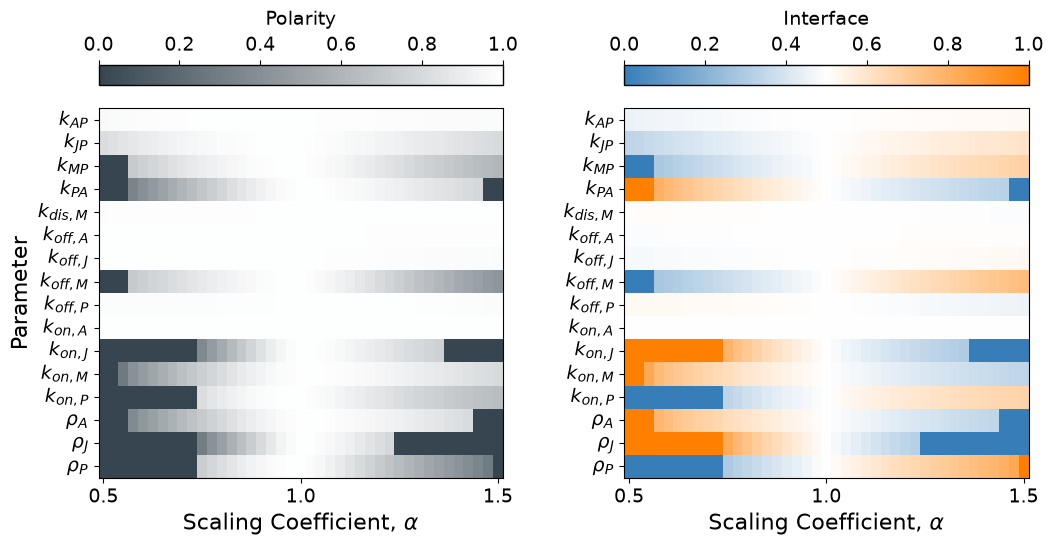

In [6]:
# Plot the heatmaps
fig, ax = plt.subplots(1, 2, figsize=(fh.page_width_fig, 6))
# Make the margines wider to accomodate the colorbar
plt.subplots_adjust(wspace=0.3)
# Heatmaps
plot_heatmap(ax[0], metrics, "polarity", cmap = fh.cmap_polarity)
plot_heatmap(ax[1], metrics, "interface", cmap = fh.cmap_interface)
_ = ax[1].set_ylabel(None)
fig.savefig(fh.FIGURES_DIR / "establishment_sensitivity_heatmaps.pdf")

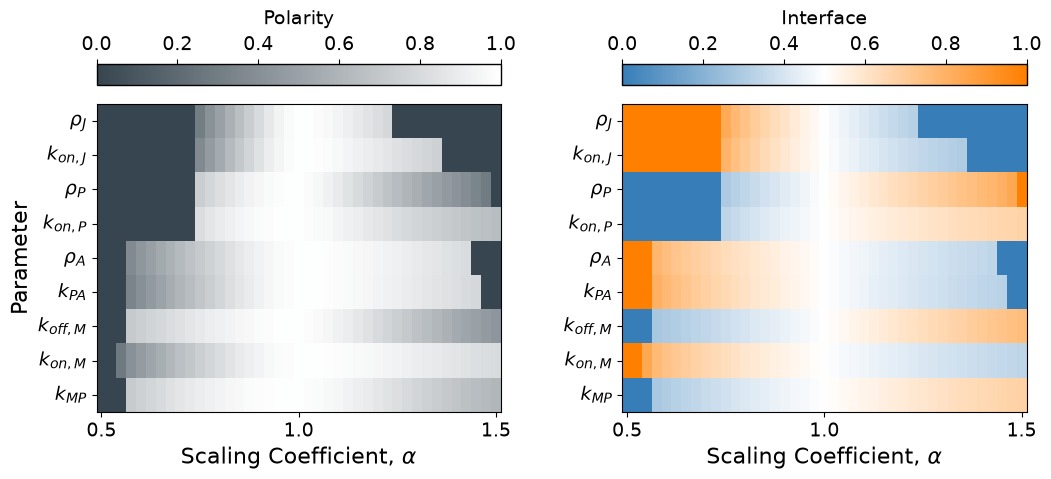

In [7]:
# Only plot parameters that have polarity values <= epsilon
# Filter and sort the parameters
polarity_threshold = 0.1 #0.75
filtered_metrics = metrics.groupby("parameter").filter(lambda x: min(x["polarity"]) <= polarity_threshold)
parameter_order = filtered_metrics.groupby("parameter")["polarity"].sum().sort_values().index
filtered_metrics["parameter"] = filtered_metrics["parameter"].astype("category")
filtered_metrics["parameter"] = filtered_metrics["parameter"].cat.reorder_categories(parameter_order, ordered = True)
filtered_metrics = filtered_metrics.sort_values(by=["parameter", "multiplier"])

fig, ax = plt.subplots(1, 2, figsize=(fh.page_width_fig, 5))
# Make the margines wider to accomodate the colorbar
plt.subplots_adjust(wspace=0.3)
# Heatmaps
plot_heatmap(ax[0], filtered_metrics, "polarity", cmap = fh.cmap_polarity)
plot_heatmap(ax[1], filtered_metrics, "interface", cmap = fh.cmap_interface)
_ = ax[1].set_ylabel(None)
fig.savefig(fh.FIGURES_DIR / "establishment_sensitivity_heatmaps-filtered.pdf")

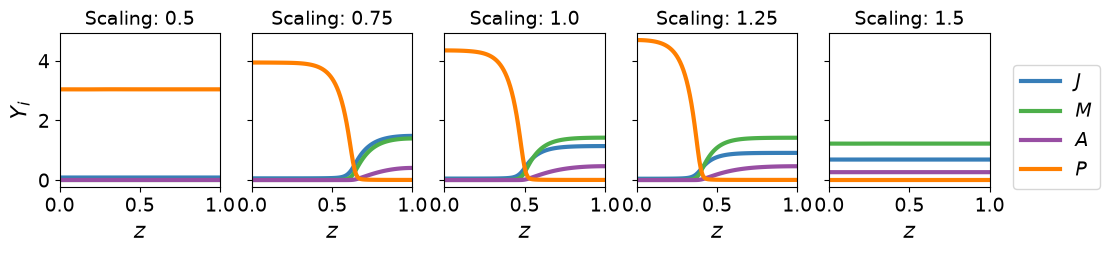

In [6]:
# Plot the final profiles for one of the parameters
param_name = "rho_A"
res_list = read_simulation_data(param_name)
plot_coefficients = [0.5, 0.75, 1.0, 1.25, 1.5]
res_list = [res for res in res_list if res[1][f"{param_name}_mult"] in plot_coefficients]

fig, axs = plt.subplots(1,len(res_list), sharey=True, figsize=(fh.page_width_fig, 2))
for i, res in enumerate(res_list):
     sol, setup = res
     fh.plot_time_point(axs[i], setup["X"], sol.y[:,-1], species = setup["Species"])
     scaling_coeff = setup[f"{param_name}_mult"]
     axs[i].set_title(f"Scaling: {scaling_coeff}", fontsize = fh.label_font_size)
     if i != 0:
          axs[i].set_ylabel(None)
fh.add_shared_legend(fig, axs)

fig.savefig(fh.FIGURES_DIR / f"establishment_{param_name}_final_profiles.pdf")

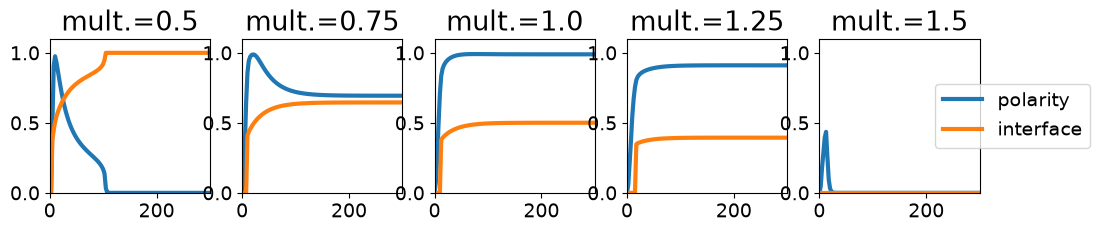

In [7]:
# Check we have reached the steady state for a parameter using the polarity/interface timeseries
param_name = "kPA"

res_list = read_simulation_data(param_name)
plot_coefficients = [0.5, 0.75, 1.0, 1.25, 1.5]
res_list = [res for res in res_list if res[1][f"{param_name}_mult"] in plot_coefficients]

fig, axs = plt.subplots(1,len(res_list), figsize=(fh.page_width_fig, 2))
axs = axs.flatten()
for i, res in enumerate(res_list):
    sol, setup = res
    timepoints = setup["t_eval"]
    polarity = [polarity_measure(setup["X"], sol.y[:,i], species = setup["Species"]) 
                for i, ti in enumerate(timepoints)]
    interface = [find_interface(setup["X"], sol.y[:,i], species = setup["Species"]) 
                for i, ti in enumerate(timepoints)]
    axs[i].plot(setup["t_eval"]/60, polarity, label = "polarity")
    axs[i].plot(setup["t_eval"]/60, interface, label = "interface")
    axs[i].set_title(f"mult.={setup[f'{param_name}_mult']}")
    axs[i].set_ylim(0,1.1)

fh.add_shared_legend(fig, axs)

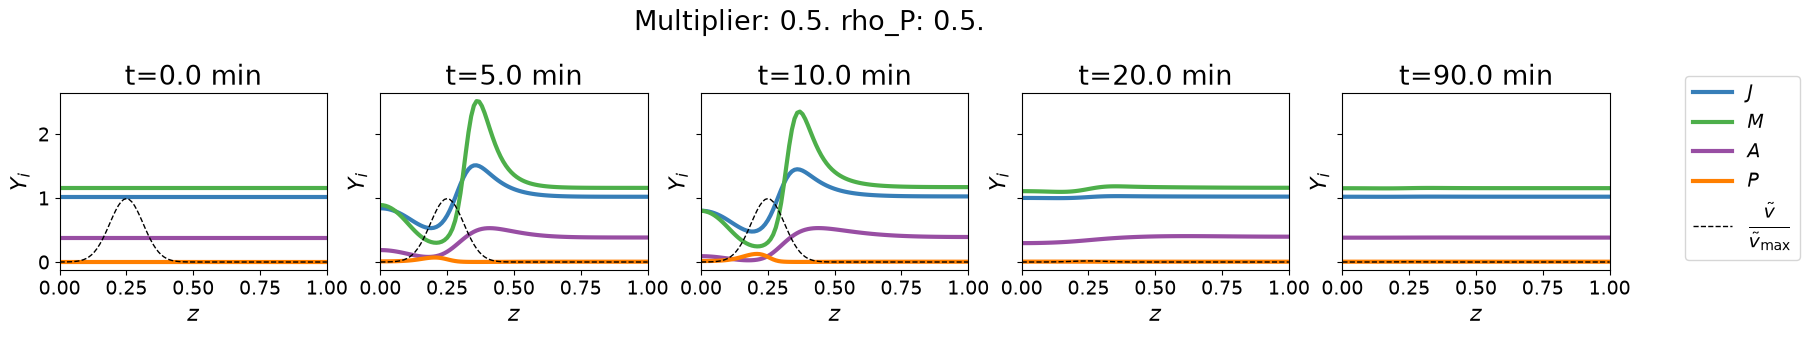

In [8]:
# Check the timeseries result for one of the parameters
param = "rho_P"
res_list = read_simulation_data(param)
sol, setup = res_list[0]
plot_times = [mins*60 for mins in [0, 5, 10, 20, 90]]
fig, axs = plt.subplots(1,len(plot_times), sharey=True)
fig.set_size_inches(20,3)
for i, time in enumerate(plot_times):
    ti = [i for i, t in enumerate(setup["t_eval"]) if t == time]
    fh.plot_time_point(axs[i], setup["X"], sol.y[:,ti], legend = False, 
                          v_func=lambda x: setup["v_func"](setup, x, time))
    axs[i].set_title(f"t={time/60:.1f} min")

fig.subplots_adjust(top=0.7)
fig.suptitle(f"Multiplier: {setup[f'{param}_mult']}. {param}: {setup[param]}.")
fh.add_shared_legend(fig, axs)
